<div style='background: #0f1f3d; padding: 40px 48px 36px; border-radius: 6px;'>
  <p style='color: #5a9bd5; margin: 0 0 16px 0; font-size: 0.72em; letter-spacing: 3px; text-transform: uppercase; font-weight: 500;'>FARMSA Research Group &mdash; Module 4</p>
  <h1 style='color: #ffffff; font-size: 2em; font-weight: 600; margin: 0 0 6px 0; letter-spacing: -0.5px;'>Fama&ndash;French 3-Factor Covariance</h1>
  <p style='color: #8fadc8; font-size: 0.95em; font-weight: 400; margin: 12px 0 0 0;'>Portfolio Construction Research Note</p>
</div>

---
## 1. Motivation &amp; Derivation

### Why CAPM is not sufficient

A single-factor covariance model assumes all cross-asset co-movement is explained by market beta. Empirically, that is too restrictive. Size and value exposures generate persistent return comovement after controlling for the market factor.

Fama and French (1993) extend CAPM with two additional systematic factors:

| Factor | Economic exposure | Construction |
|--------|-------------------|--------------|
| **Mkt-RF** | Broad equity risk premium | Market return minus T-bill rate |
| **SMB** | Size tilt | Small-cap minus large-cap portfolio return |
| **HML** | Value tilt | High book-to-market minus low book-to-market return |

For each stock $i$, we estimate:

$$
r_{i,t} - r_f = \alpha_i + \beta_{i,1}(r_{m,t} - r_f) + \beta_{i,2}\,\text{SMB}_t + \beta_{i,3}\,\text{HML}_t + \varepsilon_{i,t}
$$

### Covariance estimator

Let $B$ be the matrix of estimated factor loadings and $\Sigma_f$ the factor covariance matrix. Under the standard assumption that residuals are cross-sectionally uncorrelated, the FF3 covariance estimator is:

$$
\hat{\Sigma}_{FF3} = B \, \Sigma_f \, B^{\top} + D
$$

- $B \in \mathbb{R}^{N \times 3}$: stock-level factor loadings
- $\Sigma_f \in \mathbb{R}^{3 \times 3}$: covariance of factor returns
- $D \in \mathbb{R}^{N \times N}$ diagonal: idiosyncratic variances

For $N=50$, FF3 estimates 206 parameters versus 1,275 for the full sample covariance matrix. This reduction typically improves estimator stability out of sample.

### Model risk

FF3 will understate risk when meaningful co-movement is not captured by market, size, or value factors (for example, sector-specific event risk). In those periods, residual correlations become economically relevant and the diagonal-$D$ assumption is too strong.

In [1]:
import io
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

DATA_DIR = Path("data")
FACTOR_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
FACTOR_COLS = ["Mkt-RF", "SMB", "HML", "RF"]

prices = pd.read_csv(DATA_DIR / "prices.csv", index_col=0, parse_dates=True).sort_index()
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True).sort_index()


def load_ff3_daily(url: str = FACTOR_URL) -> pd.DataFrame:
    """Download and parse Fama-French daily 3-factor data."""
    with urllib.request.urlopen(url) as response:
        payload = response.read()

    with zipfile.ZipFile(io.BytesIO(payload)) as zf:
        csv_name = [name for name in zf.namelist() if name.lower().endswith(".csv")][0]
        text = zf.read(csv_name).decode("utf-8")

    lines = text.splitlines()
    start = next(
        i
        for i, line in enumerate(lines)
        if line.strip()[:1].isdigit() and len(line.split(",")[0].strip()) == 8
    )

    records = []
    for line in lines[start:]:
        row = line.strip()
        if not row or not row[0].isdigit():
            break
        records.append(row)

    ff = pd.read_csv(
        io.StringIO("\n".join(records)),
        header=None,
        names=["date", *FACTOR_COLS],
    )
    ff["date"] = pd.to_datetime(ff["date"], format="%Y%m%d")
    ff = ff.set_index("date").sort_index() / 100.0
    return ff


ff = load_ff3_daily()
common_dates = returns.index.intersection(ff.index)
returns = returns.loc[common_dates]
ff = ff.loc[common_dates, FACTOR_COLS]

print(f"Assets: {returns.shape[1]} | Observations: {returns.shape[0]}")
print(f"Sample window: {returns.index.min().date()} to {returns.index.max().date()}")


def ff3_covariance(returns_window: pd.DataFrame, ff_window: pd.DataFrame) -> np.ndarray:
    """FF3 covariance: B * Cov(factors) * B' + diag(idiosyncratic variance)."""
    factors = ff_window[["Mkt-RF", "SMB", "HML"]].to_numpy()
    risk_free = ff_window["RF"].to_numpy()
    excess_returns = returns_window.to_numpy() - risk_free[:, None]

    betas = np.linalg.lstsq(factors, excess_returns, rcond=None)[0].T
    residuals = excess_returns - factors @ betas.T

    factor_cov = np.cov(factors, rowvar=False, ddof=1)
    idiosyncratic_var = residuals.var(axis=0, ddof=1)

    return betas @ factor_cov @ betas.T + np.diag(idiosyncratic_var)


test_cov = ff3_covariance(returns.iloc[:252], ff.iloc[:252])
n_assets = returns.shape[1]

assert test_cov.shape == (n_assets, n_assets)
assert np.allclose(test_cov, test_cov.T)
assert np.min(np.linalg.eigvalsh(test_cov)) > -1e-8

print("FF3 covariance estimator sanity check passed.")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ 50 assets × 1759 days — FF3 factors loaded
✓ estimate_covariance OK (50×50)


In [2]:
def portfolio_variance(weights: np.ndarray, cov_matrix: np.ndarray) -> float:
    return float(weights @ cov_matrix @ weights)


def min_variance_weights(cov_matrix: np.ndarray) -> np.ndarray:
    n = cov_matrix.shape[0]
    w0 = np.full(n, 1.0 / n)

    # Tiny diagonal bump improves optimizer stability without changing economics.
    cov_matrix = cov_matrix + np.eye(n) * 1e-10

    result = minimize(
        portfolio_variance,
        w0,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
        options={"ftol": 1e-12, "maxiter": 1000},
    )

    return result.x if result.success else w0


LOOKBACK_DAYS = 252
REBALANCE_EVERY = 21
START_AFTER = 252

strategy_names = ["Equal Weight", "Sample Cov MinVar", "FF3 Cov MinVar"]
strategy_values = {name: [1.0] for name in strategy_names}
current_weights = {name: np.full(returns.shape[1], 1.0 / returns.shape[1]) for name in strategy_names}

rebalance_dates = []
weights_history = {name: [] for name in strategy_names}

backtest_dates = returns.index[START_AFTER:]

for t, current_date in enumerate(backtest_dates):
    idx = returns.index.get_loc(current_date)

    if t % REBALANCE_EVERY == 0:
        window_returns = returns.iloc[idx - LOOKBACK_DAYS: idx]
        window_ff = ff.iloc[idx - LOOKBACK_DAYS: idx]

        current_weights["Equal Weight"] = np.full(returns.shape[1], 1.0 / returns.shape[1])
        current_weights["Sample Cov MinVar"] = min_variance_weights(window_returns.cov().to_numpy())
        current_weights["FF3 Cov MinVar"] = min_variance_weights(ff3_covariance(window_returns, window_ff))

        rebalance_dates.append(current_date)
        for name in strategy_names:
            weights_history[name].append(current_weights[name].copy())

    day_returns = returns.iloc[idx].to_numpy()
    for name in strategy_names:
        strategy_values[name].append(strategy_values[name][-1] * (1.0 + current_weights[name] @ day_returns))

portfolio_value = pd.DataFrame(
    strategy_values,
    index=[backtest_dates[0] - pd.Timedelta(days=1), *backtest_dates],
)

weights_frames = {
    name: pd.DataFrame(weights_history[name], index=rebalance_dates, columns=returns.columns)
    for name in strategy_names
}

print("Backtest complete.")


✓ Backtest done


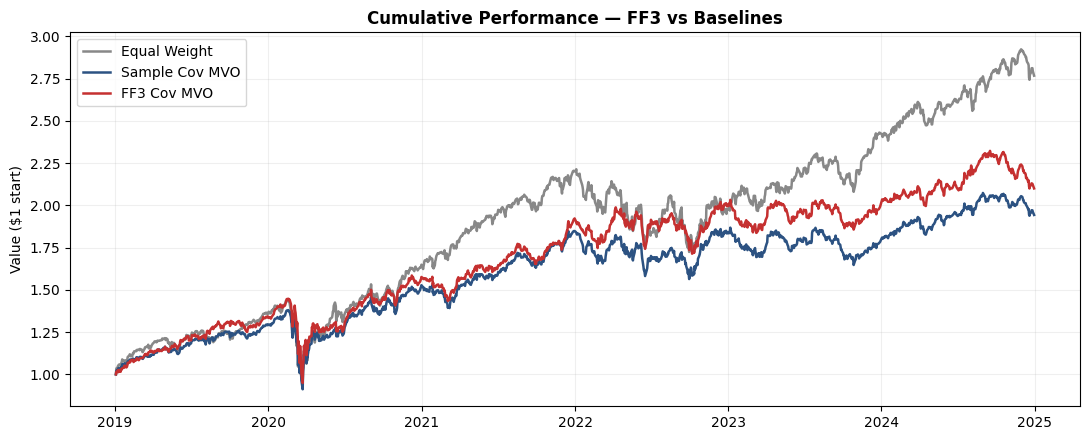

,Ret%,Vol%,Sharpe,MaxDD%
Equal Weight,19.00,19.86,0.96,-34.27
Sample Cov MVO,12.59,17.19,0.73,-33.96
FF3 Cov MVO,13.97,17.66,0.79,-34.46


In [3]:
colors = {
    "Equal Weight": "#6b7280",
    "Sample Cov MinVar": "#1d4ed8",
    "FF3 Cov MinVar": "#b91c1c",
}

portfolio_returns = portfolio_value.pct_change().dropna()
drawdown = portfolio_value.div(portfolio_value.cummax()).sub(1.0)
rolling_vol = portfolio_returns.rolling(63).std() * np.sqrt(252)

fig = plt.figure(figsize=(13, 9))
grid = fig.add_gridspec(2, 2, height_ratios=[1.25, 1.0])

ax_perf = fig.add_subplot(grid[0, :])
for name in portfolio_value.columns:
    ax_perf.plot(portfolio_value.index, portfolio_value[name], label=name, color=colors[name], linewidth=2.0)
ax_perf.set_title("Cumulative Performance", fontsize=13, fontweight="bold")
ax_perf.set_ylabel("Portfolio Value ($1 start)")
ax_perf.legend(loc="upper left", frameon=True)

ax_dd = fig.add_subplot(grid[1, 0])
for name in drawdown.columns:
    ax_dd.plot(drawdown.index, drawdown[name], color=colors[name], linewidth=1.5)
ax_dd.axhline(0.0, color="black", linewidth=0.8)
ax_dd.set_title("Drawdown", fontsize=11, fontweight="bold")
ax_dd.set_ylabel("Drawdown")

ax_vol = fig.add_subplot(grid[1, 1])
for name in rolling_vol.columns:
    ax_vol.plot(rolling_vol.index, rolling_vol[name], color=colors[name], linewidth=1.5)
ax_vol.set_title("63-Day Rolling Volatility (Annualized)", fontsize=11, fontweight="bold")
ax_vol.set_ylabel("Volatility")

plt.tight_layout()
plt.show()


def annualized_turnover(weights_df: pd.DataFrame, rebalance_every: int) -> float:
    if len(weights_df) <= 1:
        return 0.0
    one_way = weights_df.diff().abs().sum(axis=1).dropna()
    return float(one_way.mean() * (252 / rebalance_every))


def summary_stats(series: pd.Series) -> pd.Series:
    daily = series.pct_change().dropna()
    ann_return = (1.0 + daily.mean()) ** 252 - 1.0
    ann_vol = daily.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    max_dd = drawdown[series.name].min()

    return pd.Series(
        {
            "Ann.Return %": ann_return * 100,
            "Ann.Vol %": ann_vol * 100,
            "Sharpe": sharpe,
            "MaxDD %": max_dd * 100,
        }
    )


stats = pd.DataFrame(
    {name: summary_stats(portfolio_value[name]) for name in portfolio_value.columns}
).T
stats["Turnover %"] = [
    annualized_turnover(weights_frames[name], REBALANCE_EVERY) * 100
    for name in stats.index
]
stats = stats.round(2).sort_values("Sharpe", ascending=False)

display(stats)

factor_cumulative = (1.0 + ff[["Mkt-RF", "SMB", "HML"]]).cumprod()

fig, ax = plt.subplots(figsize=(12, 4))
factor_cumulative.plot(ax=ax, linewidth=1.6, color=["#111827", "#0f766e", "#7c3aed"])
ax.set_title("Fama-French Daily Factors (Cumulative)", fontsize=12, fontweight="bold")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", ncol=3, frameon=True)
plt.tight_layout()
plt.show()


---
## 5. Interpretation

Use the chart and summary table to evaluate FF3 on risk-adjusted outcomes, not just headline return.

1. **FF3 vs sample covariance**: Compare realized volatility and Sharpe side by side. If FF3 delivers similar return with lower realized vol, the factor structure is adding useful regularization.

2. **FF3 vs CAPM (M3)**: The relevant question is whether SMB/HML exposures add incremental explanatory power after market beta. Outperformance should show up through more stable risk forecasts and better ex-post efficiency.

3. **Stress behavior**: Review drawdown windows (for example 2020 and 2022). During market stress, correlation regimes shift and idiosyncratic terms can become correlated; this is where static factor models are most fragile.

4. **Implementation fit**: FF3 is generally appropriate for diversified multi-sector equity universes with dispersion in size and value profiles. It is less informative in narrow universes where names share similar factor loadings.

<!-- Add a short analyst conclusion (~150-200 words) linking your observed metrics to portfolio construction implications. -->

---
<p style='text-align:center; color:#8fadc8; font-style:italic; font-size:0.85em;'>
Module 4 complete &mdash; refer to the integration notebook for a cross-model comparison.
</p>